# Random Forest Model on Personal Transaction Data
#### Aleksa Marie Ocampo
#### CS 549 Machine Learning Spring 2026

## I. Loading Data and Imports

In [1]:
# data loading script with test splits
import sys
sys.path.insert(0, "../data")

from data_loading import load_train_test_split
X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape) 
print("features:", len(feature_cols))
print("classes:", y_train.nunique())

# imports
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
import matplotlib.pyplot as plt
print(y_train.value_counts())

train: (8644, 12) (8644,)
test:  (2162, 12) (2162,)
features: 12
classes: 5
Category_Label
0    3056
1    2980
3    1864
2     538
4     206
Name: count, dtype: int64


## II. Random Forest Baseline Model

### a) Training Baseline

In [2]:
# TRAINING BASELINE
base_rf = RandomForestClassifier(random_state=42)

base_rf.fit(X_train, y_train)
y_pred_base = base_rf.predict(X_test)

### b) Baseline Evaluation

In [3]:
# BASELINE EVALUATION
acc_base = accuracy_score(y_test, y_pred_base)
print("Baseline Accuracy:", acc_base)
print(classification_report(y_test, y_pred_base))

Baseline Accuracy: 0.35106382978723405
              precision    recall  f1-score   support

           0       0.39      0.43      0.41       764
           1       0.38      0.42      0.40       745
           2       0.16      0.06      0.09       135
           3       0.27      0.23      0.25       466
           4       0.04      0.02      0.03        52

    accuracy                           0.35      2162
   macro avg       0.25      0.23      0.23      2162
weighted avg       0.34      0.35      0.34      2162



### c) Baseline Confusion Matrix

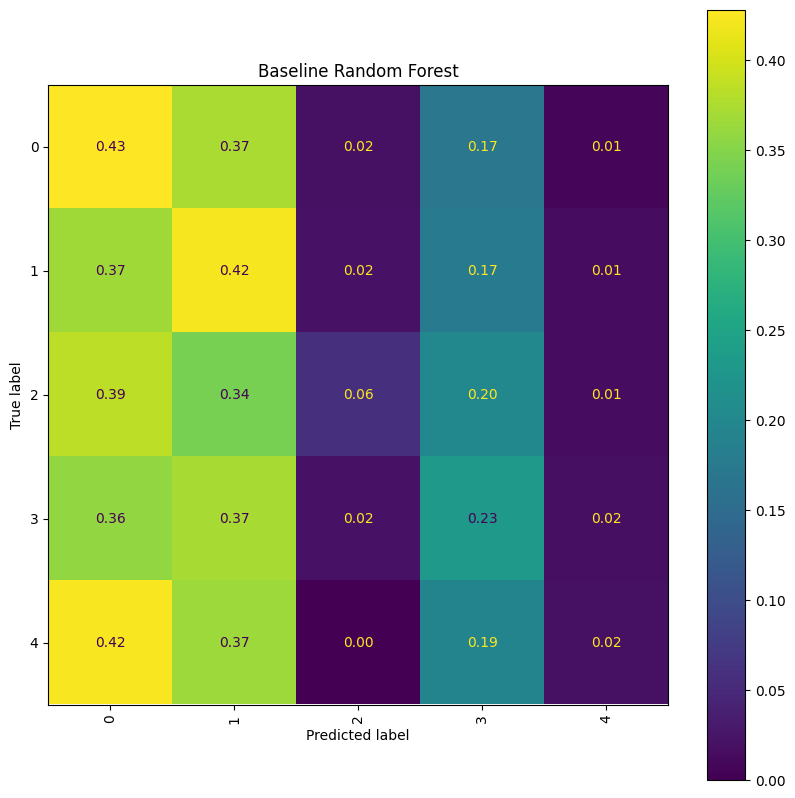

In [4]:
# VISUALIZATION: CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_base, normalize='true')

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, values_format=".2f")

plt.xticks(rotation=90)
plt.title("Baseline Random Forest")
plt.show()

## III. Baseline Model: Hyperparameter Tuning (Random Search)

### a) Tuning Baseline

In [5]:
# BASELINE HYPERPARAMETER TUNING
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30, 50],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

from sklearn.model_selection import RandomizedSearchCV
rf = RandomForestClassifier(random_state=42)

baseline_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3, # cross validation = 3
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42
)

baseline_search.fit(X_train, y_train)

best_base_rf = baseline_search.best_estimator_
y_pred_base_tuned = best_base_rf.predict(X_test)

print(baseline_search.best_params_)

/Users/aleksao/CS549/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 50}


### b) Tuned Baseline Evaluation

In [6]:
# evaluation for tuned baseline

acc_base_tuned = accuracy_score(y_test, y_pred_base_tuned)
print("Baseline Tuned Accuracy:", acc_base_tuned)
print(classification_report(y_test, y_pred_base_tuned))

Baseline Tuned Accuracy: 0.3681776133209991
              precision    recall  f1-score   support

           0       0.39      0.49      0.43       764
           1       0.36      0.46      0.41       745
           2       1.00      0.05      0.10       135
           3       0.29      0.15      0.20       466
           4       0.00      0.00      0.00        52

    accuracy                           0.37      2162
   macro avg       0.41      0.23      0.23      2162
weighted avg       0.39      0.37      0.34      2162



/Users/aleksao/CS549/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aleksao/CS549/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aleksao/CS549/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### c) Tuned Baseline Confusion Matrix

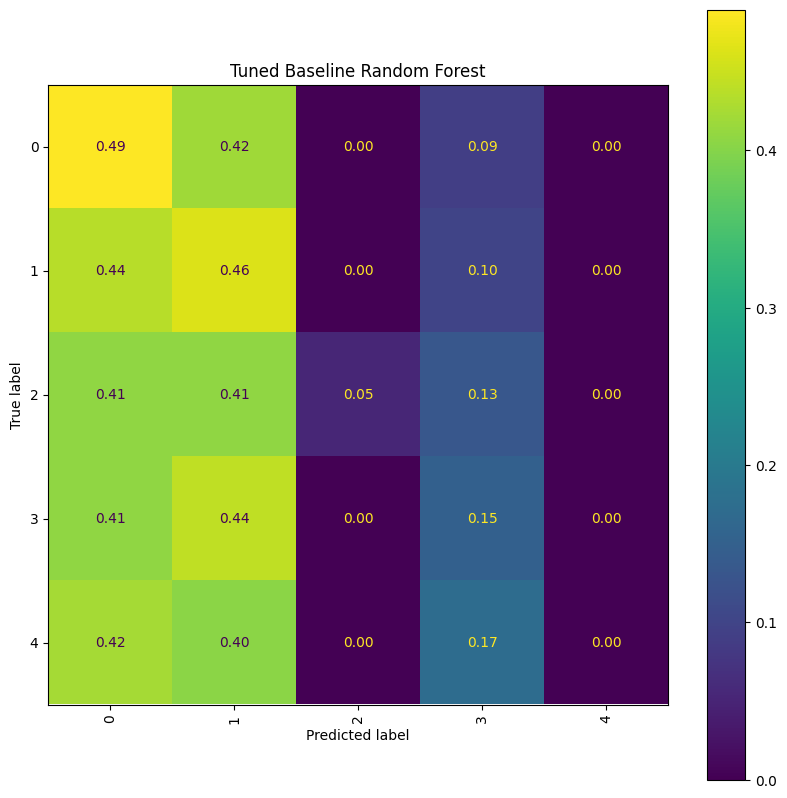

In [7]:
# confusion matrix for tuned baseline

cm = confusion_matrix(y_test, y_pred_base_tuned, normalize='true')

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, values_format=".2f")

plt.xticks(rotation=90)
plt.title("Tuned Baseline Random Forest")
plt.show()

## IV. Balanced Random Forest Model

### a) Balanced Model Training

In [8]:
# balanced model
rf_bal = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

rf_bal.fit(X_train, y_train)
y_pred_bal = rf_bal.predict(X_test)

### b) Balanced Model Evaluation

In [9]:
# evaluation for balanced

acc_bal = accuracy_score(y_test, y_pred_bal)
print("Balanced Accuracy:", acc_bal)
print(classification_report(y_test, y_pred_bal))

Balanced Accuracy: 0.34782608695652173
              precision    recall  f1-score   support

           0       0.39      0.43      0.41       764
           1       0.37      0.41      0.39       745
           2       0.17      0.06      0.09       135
           3       0.27      0.23      0.24       466
           4       0.00      0.00      0.00        52

    accuracy                           0.35      2162
   macro avg       0.24      0.23      0.23      2162
weighted avg       0.33      0.35      0.34      2162



### c) Balanced Confusion Matrix

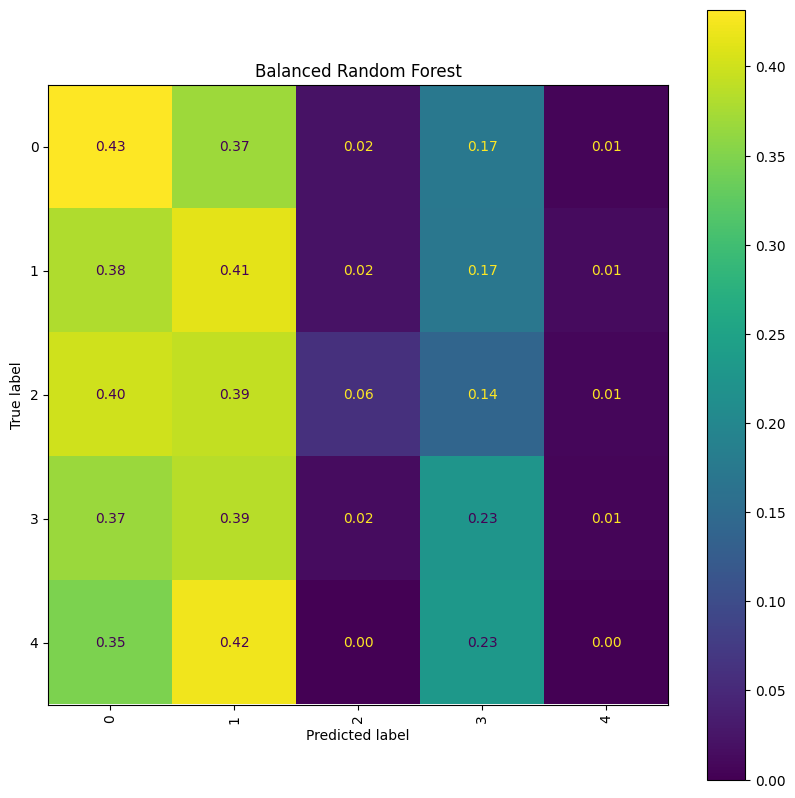

In [10]:
# confusion matrix for balanced

cm = confusion_matrix(y_test, y_pred_bal, normalize='true')

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, values_format=".2f")

plt.xticks(rotation=90)
plt.title("Balanced Random Forest")
plt.show()

## V. Balanced Random Forest: Hyperparameter Tuning (Random Search)

### a) Tuning Balanced

In [11]:
# tune balanced random forest with random search (cross validation = 3)

rf_bal = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

balanced_search = RandomizedSearchCV(
    rf_bal,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42
)

balanced_search.fit(X_train, y_train)

best_bal_rf = balanced_search.best_estimator_
y_pred_bal_tuned = best_bal_rf.predict(X_test)

print(balanced_search.best_params_)

/Users/aleksao/CS549/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 50}


### b) Tuned Balanced Evaluation

In [12]:
# evaluation for tuned balanced

acc_bal_tuned = accuracy_score(y_test, y_pred_bal_tuned)
print("Balanced Tuned Accuracy:", acc_bal_tuned)
print(classification_report(y_test, y_pred_bal_tuned))

Balanced Tuned Accuracy: 0.33209990749306195
              precision    recall  f1-score   support

           0       0.39      0.37      0.38       764
           1       0.37      0.40      0.38       745
           2       0.14      0.10      0.11       135
           3       0.25      0.26      0.26       466
           4       0.03      0.02      0.02        52

    accuracy                           0.33      2162
   macro avg       0.23      0.23      0.23      2162
weighted avg       0.33      0.33      0.33      2162



### c) Tuned Balanced Confusion Matrix

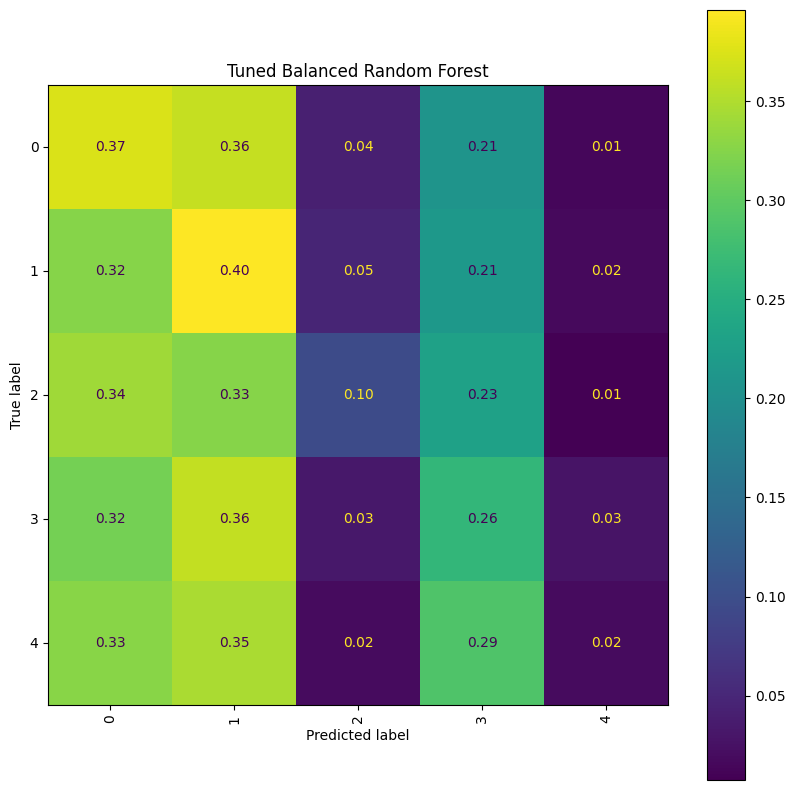

In [13]:
# confusion matrix for tuned balanced

cm = confusion_matrix(y_test, y_pred_bal_tuned, normalize='true')

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, values_format=".2f")

plt.xticks(rotation=90)
plt.title("Tuned Balanced Random Forest")
plt.show()

## VI. Final Comparison

In [14]:
# final summary / model comparison

print("\n=== MODEL COMPARISON ===")
print("\n===== BASELINE MODEL =====")
print(classification_report(y_test, y_pred_base))
print(f"Baseline:            {acc_base:.4f}")
print("\n===== BASELINE TUNED MODEL =====")
print(classification_report(y_test, y_pred_base_tuned))
print(f"Baseline Tuned:      {acc_base_tuned:.4f}")
print("\n===== BALANCED MODEL =====")
print(classification_report(y_test, y_pred_bal))
print(f"Balanced:            {acc_bal:.4f}")
print("\n===== BALANCED TUNED MODEL =====")
print(classification_report(y_test, y_pred_bal_tuned))
print(f"Balanced Tuned:      {acc_bal_tuned:.4f}")


=== MODEL COMPARISON ===

===== BASELINE MODEL =====
              precision    recall  f1-score   support

           0       0.39      0.43      0.41       764
           1       0.38      0.42      0.40       745
           2       0.16      0.06      0.09       135
           3       0.27      0.23      0.25       466
           4       0.04      0.02      0.03        52

    accuracy                           0.35      2162
   macro avg       0.25      0.23      0.23      2162
weighted avg       0.34      0.35      0.34      2162

Baseline:            0.3511

===== BASELINE TUNED MODEL =====
              precision    recall  f1-score   support

           0       0.39      0.49      0.43       764
           1       0.36      0.46      0.41       745
           2       1.00      0.05      0.10       135
           3       0.29      0.15      0.20       466
           4       0.00      0.00      0.00        52

    accuracy                           0.37      2162
   macro avg   

/Users/aleksao/CS549/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aleksao/CS549/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/aleksao/CS549/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Precision,Recall,F1-Score,Support
0,0.387,0.490,0.432,764.000
1,0.364,0.463,0.408,745.000
2,1.000,0.052,0.099,135.000
3,0.289,0.150,0.198,466.000
4,0.000,0.000,0.000,52.000
accuracy,0.368,0.368,0.368,0.368
macro avg,0.408,0.231,0.227,2162.000
weighted avg,0.387,0.368,0.342,2162.000


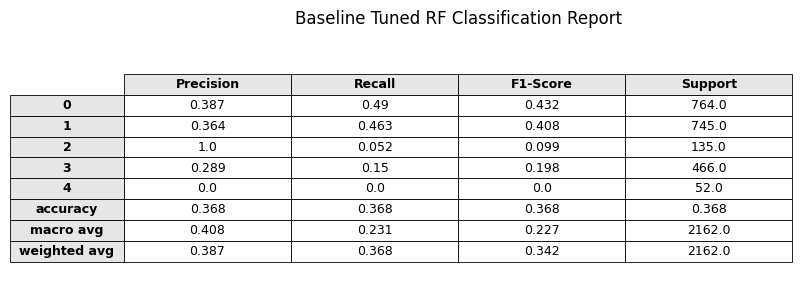

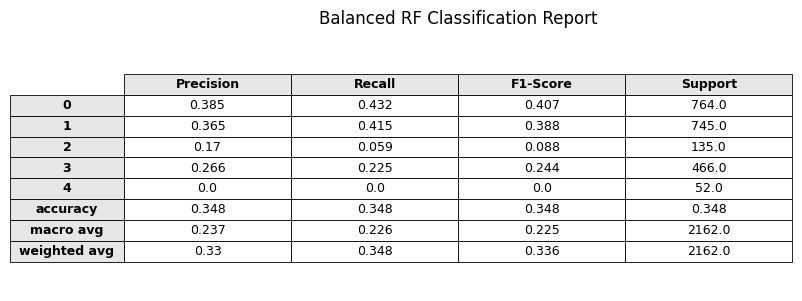

In [15]:
# =========================================================
# BASELINE TUNED RF CLASSIFICATION REPORT
# =========================================================

baseline_tuned_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_base_tuned,
        output_dict=True,
        zero_division=0
    )
).transpose()

baseline_tuned_report_df = baseline_tuned_report_df.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1-Score",
    "support": "Support"
}).round(3)

display(baseline_tuned_report_df)


# ----- IMAGE -----

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.axis("off")

table = ax.table(
    cellText=baseline_tuned_report_df.values,
    colLabels=baseline_tuned_report_df.columns,
    rowLabels=baseline_tuned_report_df.index,
    loc="center",
    cellLoc="center",
    rowLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.15, 1.25)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.6)

    if row == 0:
        cell.set_facecolor("#E6E6E6")
        cell.set_text_props(weight="bold")

    if col == -1:
        cell.set_facecolor("#E6E6E6")
        cell.set_text_props(weight="bold")

plt.title("Baseline Tuned RF Classification Report", pad=15)

plt.savefig(
    "baseline_tuned_rf_report.png",
    bbox_inches="tight",
    dpi=300,
    pad_inches=0.05
)

plt.show()


# =========================================================
# BALANCED TUNED RF CLASSIFICATION REPORT
# =========================================================

balanced_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_bal,
        output_dict=True,
        zero_division=0
    )
).transpose()

balanced_report_df = balanced_report_df.rename(columns={
    "precision": "Precision",
    "recall": "Recall",
    "f1-score": "F1-Score",
    "support": "Support"
}).round(3)

balanced_report_df


# ----- IMAGE -----

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.axis("off")

table = ax.table(
    cellText=balanced_report_df.values,
    colLabels=balanced_report_df.columns,
    rowLabels=balanced_report_df.index,
    loc="center",
    cellLoc="center",
    rowLoc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.15, 1.25)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.6)

    if row == 0:
        cell.set_facecolor("#E6E6E6")
        cell.set_text_props(weight="bold")

    if col == -1:
        cell.set_facecolor("#E6E6E6")
        cell.set_text_props(weight="bold")

plt.title("Balanced RF Classification Report", pad=15)

plt.savefig(
    "balanced_report.png",
    bbox_inches="tight",
    dpi=300,
    pad_inches=0.05
)

plt.show()

## VII. Random Forest Feature Importance

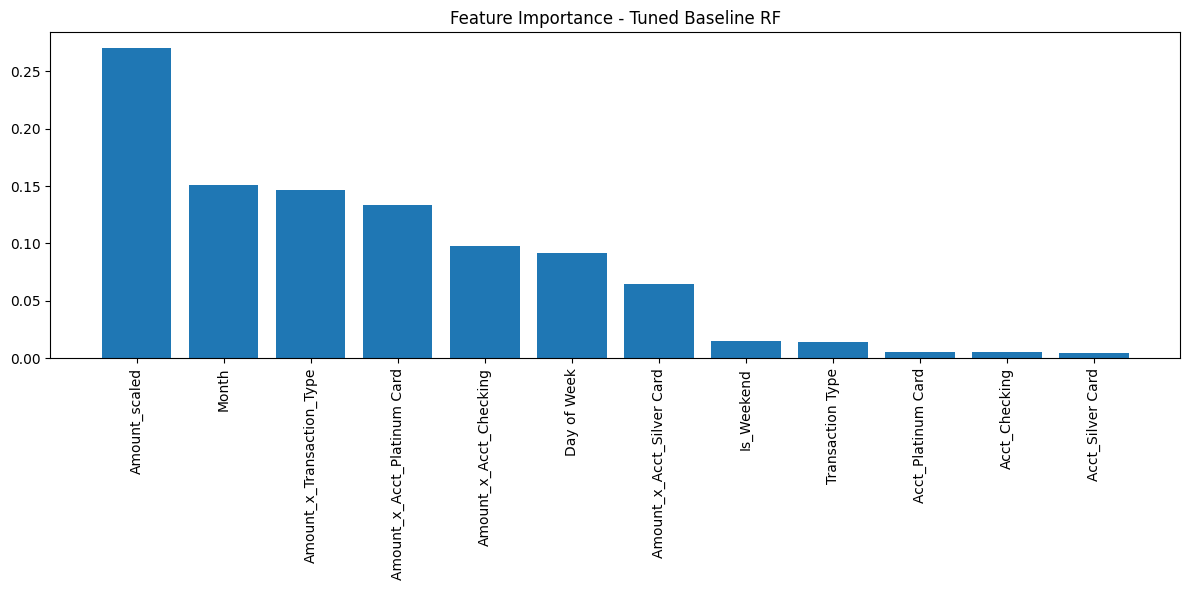

In [16]:
import numpy as np
import matplotlib.pyplot as plt

importances = best_base_rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importance - Tuned Baseline RF")

plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), np.array(feature_cols)[indices], rotation=90)

plt.tight_layout()
plt.show()